# TSB + XGBoost — Epoch-Based Training & Pickle Export
**Use for:** INTERMITTENT or LUMPY demand (ADI ≥ 1.32)

## What this notebook does
1. Loads the TSB-specific dataset and verifies demand classification
2. Runs **epoch-based walk-forward validation** — each epoch expands the training
   window by 1 month and re-fits TSB+XGB from scratch
3. After all epochs, trains the **final model** on the complete dataset
4. **Saves every artefact to pickle** for production reuse
5. Demonstrates **loading from pickle** and running inference

## Why TSB for Intermittent Demand?
Standard ARIMA assumes a continuously populated series. TSB handles zeros explicitly:
- **z(t)** tracks demand *size* (smoothed with α)
- **p(t)** tracks demand *probability* (smoothed with β)
- **Forecast** = p(t) × z(t)

The XGBoost layer corrects non-linear residuals that TSB misses.

## Epoch Design (identical walk-forward strategy)
```
│← train window (grows) →│← eval window (H months) →│
│███████████████████████│░░░░░░░░░░░░░░░░░░░░░░░░░░│  epoch 1
│████████████████████████│░░░░░░░░░░░░░░░░░░░░░░░░░░│  epoch 2
│█████████████████████████│░░░░░░░░░░░░░░░░░░░░░░░░░│  epoch 3
```
> **MAPE note:** For intermittent demand, MAPE is computed only on non-zero actual months.
> Zero months are excluded to avoid division-by-zero — this is standard practice.


## 1. Imports & Style

In [1]:
import warnings, pickle, os, time
from pathlib import Path
from itertools import product as cartesian
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot
from statsmodels.graphics.tsaplots import plot_acf
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.35,'grid.linestyle':'--',
    'font.size':11,'axes.titlesize':13,'axes.titleweight':'bold',
    'axes.spines.top':False,'axes.spines.right':False
})
ORANGE,PURPLE,BLUE,GREEN,GRAY='#FF6B00','#8b5cf6','#3b82f6','#10b981','#94a3b8'
print('✅  Libraries loaded')

✅  Libraries loaded


## 2. Configuration

In [2]:
CSV_PATH   = 'sales_tsb_5yr.csv'       # <-- update if needed
PICKLE_DIR = Path('autoparts-backend/python/trained_models/tsb_xgb')
PICKLE_DIR.mkdir(parents=True, exist_ok=True)

# TSB smoothing parameter grids (mirrors tsb_xgb_model.py)
ALPHA_GRID_INITIAL  = [0.1,0.2,0.3,0.4,0.5]
BETA_GRID_INITIAL   = [0.1,0.2,0.3,0.4,0.5]
ALPHA_GRID_EXTENDED = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.6,0.7]
BETA_GRID_EXTENDED  = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.6,0.7]

XGB_PARAMS = dict(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)

LAG_FEATURES    = [1,2,3,6,12]
ROLLING_WINDOWS = [3,6]

# Walk-forward config
MIN_TRAIN_MONTHS = 24
EVAL_HORIZON     = 3
N_EPOCHS         = 12

FINAL_TEST_SIZE  = 6
CI_ALPHA         = 0.05
POOR_MAPE_THR    = 25.0

print(f'TSB initial grid: {len(ALPHA_GRID_INITIAL)}×{len(BETA_GRID_INITIAL)} = '
      f'{len(ALPHA_GRID_INITIAL)*len(BETA_GRID_INITIAL)} combinations')
print(f'TSB extended grid: {len(ALPHA_GRID_EXTENDED)}×{len(BETA_GRID_EXTENDED)} = '
      f'{len(ALPHA_GRID_EXTENDED)*len(BETA_GRID_EXTENDED)} combinations')
print(f'Epochs: {N_EPOCHS}  |  Eval horizon: {EVAL_HORIZON} months  |  Min train: {MIN_TRAIN_MONTHS} months')

TSB initial grid: 5×5 = 25 combinations
TSB extended grid: 12×12 = 144 combinations
Epochs: 12  |  Eval horizon: 3 months  |  Min train: 24 months


## 3. Load Dataset & Verify Classification

In [3]:
df_raw = pd.read_csv(CSV_PATH, parse_dates=['date'])
df_raw['year_month'] = df_raw['date'].dt.to_period('M')
monthly = (
    df_raw.groupby(['year_month','product_name'])
    .agg(total_qty=('quantity','sum'))
    .reset_index()
)
all_months = pd.period_range(monthly['year_month'].min(),
                              monthly['year_month'].max(), freq='M')
print(f'Rows: {len(df_raw):,}  |  Monthly periods: {len(all_months)}')

# Demand classification + zero-rate
print(f'\n{"Product":<28} {"ADI":>6} {"CV²":>7} {"Zero%":>7} {"Type":<14} {"Model"}')
print('─'*75)
tsb_products = []
for prod in sorted(monthly['product_name'].unique()):
    s   = monthly[monthly['product_name']==prod].set_index('year_month')['total_qty']
    arr = s.reindex(all_months, fill_value=0).values.astype(float)
    nz  = arr[arr>0]
    adi = len(arr)/len(nz) if len(nz) else float('inf')
    cv2 = ((nz.std(ddof=1)/nz.mean())**2) if (len(nz)>1 and nz.mean()>0) else 0
    z_pct = (arr==0).mean()*100
    dtype = ('Smooth' if adi<1.32 and cv2<0.49 else
             'Erratic' if adi<1.32 else
             'Intermittent' if cv2<0.49 else 'Lumpy')
    model = 'TSB_XGB ✓' if adi>=1.32 else 'ARIMA_XGB'
    print(f'{prod:<28} {adi:>6.2f} {cv2:>7.3f} {z_pct:>6.1f}% {dtype:<14} {model}')
    if adi >= 1.32:
        tsb_products.append(prod)
print(f'\n→ TSB+XGB products: {tsb_products}')

Rows: 316  |  Monthly periods: 60

Product                         ADI     CV²   Zero% Type           Model
───────────────────────────────────────────────────────────────────────────
Catalytic Converter            2.07   0.312   51.7% Intermittent   TSB_XGB ✓
Gearbox Assembly               2.86   0.883   65.0% Lumpy          TSB_XGB ✓
Hydraulic Pump Seal Kit        2.00   0.619   50.0% Lumpy          TSB_XGB ✓
Industrial O-Ring Kit          2.61   0.681   61.7% Lumpy          TSB_XGB ✓
Timing Chain Tensioner         2.00   0.370   50.0% Intermittent   TSB_XGB ✓
Turbocharger Assembly          2.50   0.414   60.0% Intermittent   TSB_XGB ✓

→ TSB+XGB products: ['Catalytic Converter', 'Gearbox Assembly', 'Hydraulic Pump Seal Kit', 'Industrial O-Ring Kit', 'Timing Chain Tensioner', 'Turbocharger Assembly']


## 4. Helper Functions

In [4]:
def get_series(prod):
    s = monthly[monthly['product_name']==prod].set_index('year_month')['total_qty']
    return s.reindex(all_months, fill_value=0).astype(float)


def run_tsb(series, alpha, beta):
    n, z, p = len(series), np.zeros(len(series)), np.zeros(len(series))
    nz = [s for s in series if s > 0]
    z[0] = nz[0] if nz else 1.0
    p[0] = len(nz)/n
    for t in range(1, n):
        if series[t] > 0:
            z[t] = alpha*series[t] + (1-alpha)*z[t-1]
            p[t] = beta + (1-beta)*p[t-1]
        else:
            z[t] = z[t-1]
            p[t] = (1-beta)*p[t-1]
    return p*z


def tsb_grid_search(series, alpha_grid, beta_grid):
    best_mse, best_a, best_b = np.inf, alpha_grid[0], beta_grid[0]
    for a, b in cartesian(alpha_grid, beta_grid):
        fitted = run_tsb(series, a, b)
        mse    = np.mean((series-fitted)**2)
        if mse < best_mse:
            best_mse, best_a, best_b = mse, a, b
    return best_a, best_b, best_mse


def build_features(residuals):
    df = pd.DataFrame({'v': pd.Series(residuals)})
    for lag in LAG_FEATURES:
        df[f'lag_{lag}'] = df['v'].shift(lag)
    for w in ROLLING_WINDOWS:
        df[f'rmean_{w}'] = df['v'].shift(1).rolling(w).mean()
        df[f'rstd_{w}']  = df['v'].shift(1).rolling(w).std()
    df = df.dropna()
    return df, [c for c in df.columns if c != 'v']


def extract_feat(window):
    feats = [window[-lag] if len(window)>=lag else 0.0 for lag in LAG_FEATURES]
    for w in ROLLING_WINDOWS:
        sl = window[-w:] if len(window)>=w else window
        feats += [float(np.mean(sl)), float(np.std(sl)) if len(sl)>1 else 0.0]
    return feats


def compute_metrics(actual, predicted, label=''):
    a, p  = np.array(actual,float), np.array(predicted,float)
    mse   = float(mean_squared_error(a, p))
    rmse  = float(np.sqrt(mse))
    mae   = float(mean_absolute_error(a, p))
    nz    = a != 0
    # MAPE on non-zero months only (standard for intermittent demand)
    mape  = float(np.mean(np.abs((a[nz]-p[nz])/a[nz]))*100) if nz.any() else np.nan
    # NZ-RMSE: RMSE on non-zero months only
    nz_rmse = float(np.sqrt(mean_squared_error(a[nz],p[nz]))) if nz.any() else np.nan
    acc   = round(100-mape,2) if not np.isnan(mape) else np.nan
    return dict(label=label, MSE=round(mse,4), RMSE=round(rmse,4),
                MAE=round(mae,4), MAPE=round(mape,2), Accuracy=acc,
                NZ_RMSE=round(nz_rmse,4))


def train_tsb_xgb(train_arr, horizon, alpha_grid, beta_grid, xgb_params=XGB_PARAMS):
    """
    Full TSB+XGB training on train_arr, forecast horizon steps.
    Returns dict of all artefacts.
    """
    best_a, best_b, _ = tsb_grid_search(train_arr, alpha_grid, beta_grid)
    tsb_fitted        = run_tsb(train_arr, best_a, best_b)
    residuals         = train_arr - tsb_fitted

    df_feat, fc = build_features(residuals)
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(df_feat[fc])
    xgb_mod = xgb.XGBRegressor(**xgb_params)
    xgb_mod.fit(X_sc, df_feat['v'], verbose=False)

    tsb_fc_base = np.full(horizon, float(tsb_fitted[-1]))
    xgb_corr    = []
    window = list(residuals)
    for _ in range(horizon):
        feat = extract_feat(window)
        c    = float(xgb_mod.predict(scaler.transform([feat]))[0])
        xgb_corr.append(c); window.append(c)

    final_fc = np.maximum(0, tsb_fc_base + np.array(xgb_corr))
    ci_hw    = norm.ppf(1-CI_ALPHA/2) * float(np.std(residuals))

    return dict(
        forecast=final_fc, xgb_model=xgb_mod, scaler=scaler,
        tsb_fitted=tsb_fitted, residuals=residuals, ci_hw=ci_hw,
        best_alpha=best_a, best_beta=best_b
    )


print('✅  Helper functions defined')

✅  Helper functions defined


## 5. Epoch-Based Walk-Forward Validation

For intermittent demand, each epoch fits a fresh TSB grid-search + XGBoost on the
expanding training window, then evaluates on the next `EVAL_HORIZON` months.
MAPE is reported on **non-zero months only**.


In [5]:
epoch_results = {}

for prod in tsb_products:
    series = get_series(prod).values.astype(float)
    n      = len(series)
    max_start = n - EVAL_HORIZON - 1
    if MIN_TRAIN_MONTHS > max_start:
        print(f'⚠  {prod}: not enough data, skipping')
        continue

    epoch_starts = list(range(MIN_TRAIN_MONTHS,
                              min(MIN_TRAIN_MONTHS+N_EPOCHS, max_start+1)))

    print(f'\n{"═"*68}')
    print(f'  {prod}  —  {len(epoch_starts)} epochs')
    print(f'{"─"*68}')
    print(f'  {"Epoch":>5}  {"TrainN":>7}  '
          f'{"NZmonths":>8}  {"MSE":>10}  {"RMSE":>8}  {"MAE":>8}  {"MAPE%":>7}  {"Acc%":>6}  {"Time":>6}')
    print(f'  {"─"*5}  {"─"*7}  {"─"*8}  {"─"*10}  {"─"*8}  {"─"*8}  {"─"*7}  {"─"*6}  {"─"*6}')

    records = []
    for ep_idx, train_end in enumerate(epoch_starts, start=1):
        train_arr   = series[:train_end]
        eval_actual = series[train_end:train_end+EVAL_HORIZON]
        if len(eval_actual) < EVAL_HORIZON: break

        t0      = time.perf_counter()
        result  = train_tsb_xgb(train_arr, EVAL_HORIZON,
                                 ALPHA_GRID_INITIAL, BETA_GRID_INITIAL)
        elapsed = time.perf_counter() - t0

        met = compute_metrics(eval_actual, result['forecast'], label=f'Epoch {ep_idx}')
        nz_count = int((eval_actual > 0).sum())
        met.update(dict(epoch=ep_idx, train_n=train_end,
                         nz_eval=nz_count,
                         best_alpha=result['best_alpha'],
                         best_beta=result['best_beta'],
                         elapsed_s=round(elapsed,2)))
        records.append(met)

        flag = ' ⚠' if (not np.isnan(met['MAPE']) and met['MAPE']>=POOR_MAPE_THR) else ''
        mape_str = f'{met["MAPE"]:>6.1f}%' if not np.isnan(met['MAPE']) else '    N/A'
        acc_str  = f'{met["Accuracy"]:>5.1f}%' if not np.isnan(met['Accuracy']) else '  N/A'
        print(f'  Epoch {ep_idx:>2d}   {train_end:>6d}   {nz_count:>8d}   '
              f'{met["MSE"]:>10.3f}  {met["RMSE"]:>8.3f}  {met["MAE"]:>8.3f}  '
              f'{mape_str}  {acc_str}  {elapsed:>5.1f}s{flag}')

    epoch_results[prod] = records

print('\n✅  Walk-forward validation complete')
print('  (N/A MAPE = all eval months were zero — no non-zero actuals to measure against)')


════════════════════════════════════════════════════════════════════
  Catalytic Converter  —  12 epochs
────────────────────────────────────────────────────────────────────
  Epoch   TrainN  NZmonths         MSE      RMSE       MAE    MAPE%    Acc%    Time
  ─────  ───────  ────────  ──────────  ────────  ────────  ───────  ──────  ──────
  Epoch  1       24          3        0.513     0.716     0.632    18.1%   81.9%    0.1s
  Epoch  2       25          2       11.881     3.447     2.033     1.1%   98.9%    0.1s
  Epoch  3       26          1        5.638     2.374     1.975     6.9%   93.1%    0.0s
  Epoch  4       27          0       33.560     5.793     5.760      N/A    N/A    0.1s
  Epoch  5       28          1        4.277     2.068     2.026    25.9%   74.1%    0.0s ⚠
  Epoch  6       29          1        3.382     1.839     1.484    36.7%   63.3%    0.1s ⚠
  Epoch  7       30          1        0.788     0.888     0.513    22.0%   78.0%    0.1s
  Epoch  8       31          0 

## 6. Epoch Metric Plots

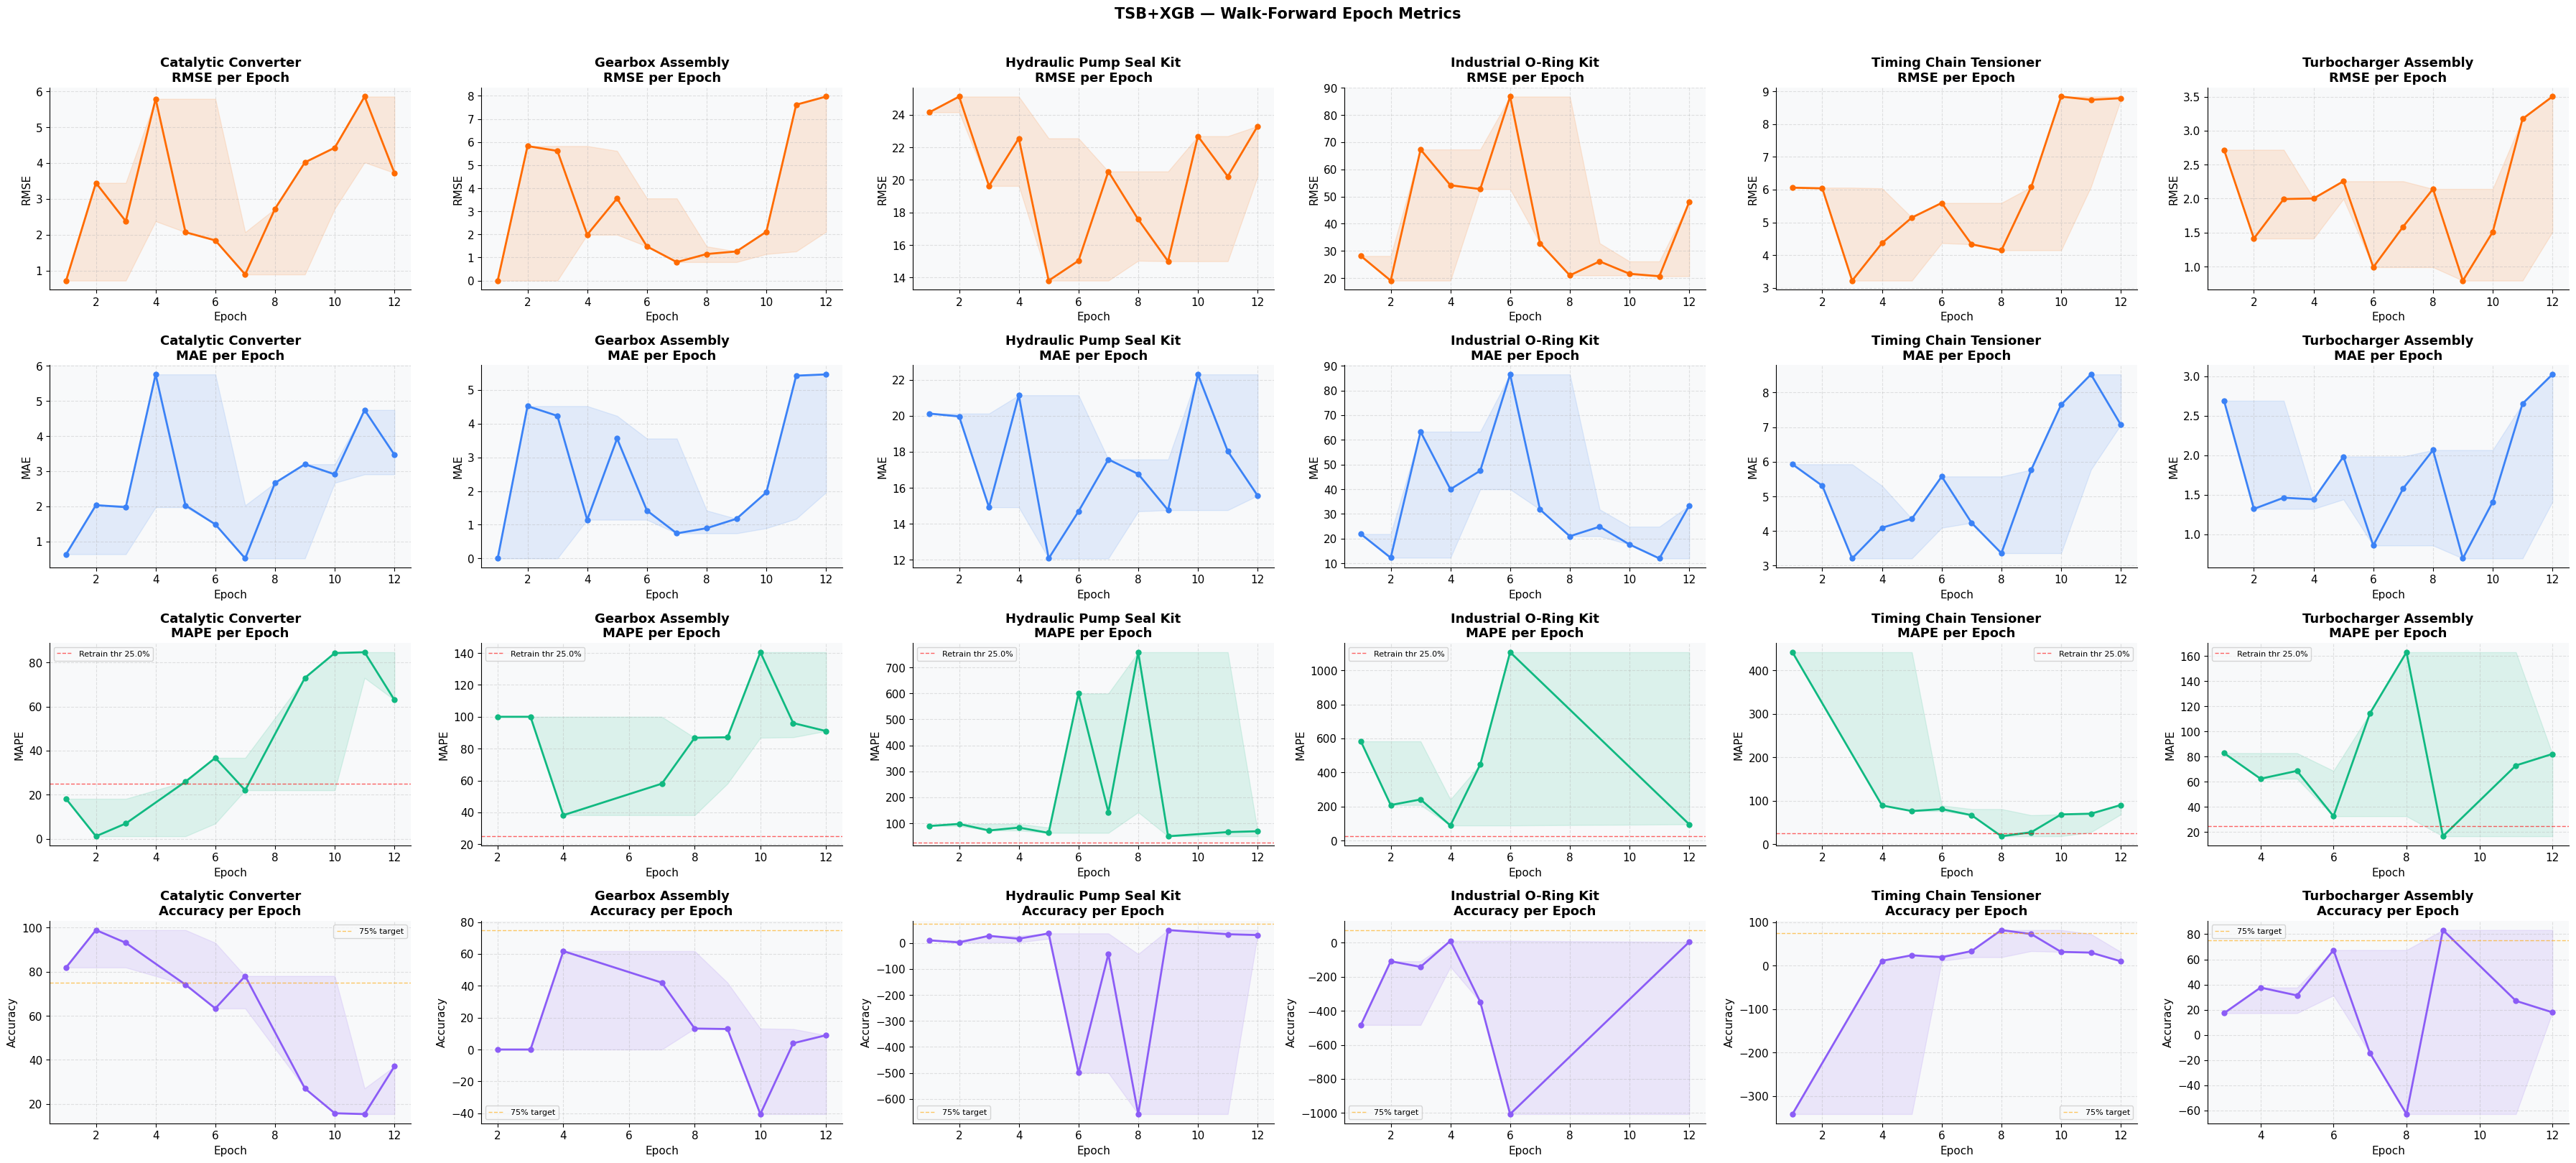

Saved: tsb_epoch_metrics.png


In [6]:
n_prods = len(epoch_results)
fig, axes = plt.subplots(4, n_prods, figsize=(6*n_prods, 16))
if n_prods == 1: axes = axes.reshape(4,1)
metrics_to_plot = ['RMSE','MAE','MAPE','Accuracy']
colors_m = [ORANGE,BLUE,GREEN,PURPLE]

for col, (prod, records) in enumerate(epoch_results.items()):
    ep_df = pd.DataFrame(records)
    for row, (metric, color) in enumerate(zip(metrics_to_plot, colors_m)):
        ax = axes[row, col]
        valid = ep_df.dropna(subset=[metric])
        ax.plot(valid['epoch'], valid[metric], color=color, lw=2, marker='o', ms=5)
        if len(valid) > 2:
            ax.fill_between(valid['epoch'],
                            valid[metric].rolling(3,min_periods=1).min(),
                            valid[metric].rolling(3,min_periods=1).max(),
                            alpha=0.12, color=color)
        if metric == 'MAPE':
            ax.axhline(POOR_MAPE_THR, color='red', ls='--', lw=1, alpha=0.6,
                       label=f'Retrain thr {POOR_MAPE_THR}%')
            ax.legend(fontsize=8)
        if metric == 'Accuracy':
            ax.axhline(75, color='orange', ls='--', lw=1, alpha=0.6, label='75% target')
            ax.legend(fontsize=8)
        ax.set_xlabel('Epoch'); ax.set_ylabel(metric)
        ax.set_title(f'{prod}\n{metric} per Epoch')

plt.suptitle('TSB+XGB — Walk-Forward Epoch Metrics',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tsb_epoch_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: tsb_epoch_metrics.png')

In [7]:
# Epoch summary table
print(f'{"═"*76}')
print('  TSB+XGB Epoch Summary — Mean ± Std  (MAPE on non-zero months only)')
print(f'{"─"*76}')
print(f'  {"Product":<28} {"RMSE":>12} {"MAE":>12} {"MAPE%":>12} {"Acc%":>12}')
print(f'{"─"*76}')
for prod, records in epoch_results.items():
    df = pd.DataFrame(records)
    def fmt(col):
        v = df[col].dropna()
        return f'{v.mean():>6.2f}±{v.std():>4.2f}' if len(v) else '        N/A'
    print(f'  {prod:<28} {fmt("RMSE")}  {fmt("MAE")}  {fmt("MAPE")}  {fmt("Accuracy")}')
print(f'{"═"*76}')

════════════════════════════════════════════════════════════════════════════
  TSB+XGB Epoch Summary — Mean ± Std  (MAPE on non-zero months only)
────────────────────────────────────────────────────────────────────────────
  Product                              RMSE          MAE        MAPE%         Acc%
────────────────────────────────────────────────────────────────────────────
  Catalytic Converter            3.16±1.70    2.62±1.55   41.55±31.92   58.45±31.92
  Gearbox Assembly               3.28±2.77    2.54±1.96   88.65±28.49   11.35±28.49
  Hydraulic Pump Seal Kit       19.96±3.84   17.33±3.09  190.26±245.55  -90.26±245.55
  Industrial O-Ring Kit         39.87±21.86   34.32±22.31  395.83±362.17  -295.83±362.17
  Timing Chain Tensioner         5.95±1.92    5.42±1.68  103.05±121.41   -3.05±121.41
  Turbocharger Assembly          2.01±0.82    1.77±0.73   77.32±42.97   22.68±42.97
════════════════════════════════════════════════════════════════════════════


## 7. Final Model Training (Full Dataset → Pickle)

In [8]:
final_models  = {}
final_metrics = []

print(f'Training final models (test holdout = last {FINAL_TEST_SIZE} months)...\n')

for prod in tsb_products:
    full_arr    = get_series(prod).values.astype(float)
    full_idx    = get_series(prod).index
    train_arr   = full_arr[:-FINAL_TEST_SIZE]
    test_actual = full_arr[-FINAL_TEST_SIZE:]

    t0      = time.perf_counter()
    result  = train_tsb_xgb(train_arr, FINAL_TEST_SIZE,
                              ALPHA_GRID_INITIAL, BETA_GRID_INITIAL)
    elapsed = time.perf_counter() - t0

    met = compute_metrics(test_actual, result['forecast'])

    # ── Pickle bundle ──────────────────────────────────────────────────────────
    bundle = {
        'product':        prod,
        'algorithm':      'TSB_XGB',
        'best_alpha':     result['best_alpha'],
        'best_beta':      result['best_beta'],
        'xgb_model':      result['xgb_model'],
        'scaler':         result['scaler'],
        'tsb_fitted':     result['tsb_fitted'],
        'residuals':      result['residuals'],
        'ci_hw':          result['ci_hw'],
        'lag_features':   LAG_FEATURES,
        'rolling_windows':ROLLING_WINDOWS,
        'train_index':    [str(p) for p in full_idx[:-FINAL_TEST_SIZE]],
        'train_values':   train_arr.tolist(),
        'metrics':        met,
        'xgb_params':     XGB_PARAMS,
        'alpha_grid':     ALPHA_GRID_INITIAL,
        'beta_grid':      BETA_GRID_INITIAL,
        'trained_at':     pd.Timestamp.now().isoformat(),
        'n_train':        len(train_arr),
        'horizon':        FINAL_TEST_SIZE,
        'ci_alpha':       CI_ALPHA,
    }

    pkl_path = PICKLE_DIR / f'{prod.lower().replace(" ","_").replace("/","_").replace("-","_")}.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)

    final_models[prod] = {**bundle, 'forecast':result['forecast'],
                           'test_actual':test_actual,
                           'full_arr':full_arr, 'full_idx':full_idx}
    final_metrics.append({'Product':prod, **met})

    mape_str = f'{met["MAPE"]:>5.1f}%' if not np.isnan(met['MAPE']) else '  N/A'
    print(f'  ✅  {prod:<30} α={result["best_alpha"]}  β={result["best_beta"]}  '
          f'MAPE={mape_str}  RMSE={met["RMSE"]:>7.2f}  → {pkl_path.name}  ({elapsed:.1f}s)')

metrics_df = pd.DataFrame(final_metrics)
print(f'\nAll models pickled to: {PICKLE_DIR.resolve()}')

Training final models (test holdout = last 6 months)...

  ✅  Catalytic Converter            α=0.5  β=0.5  MAPE= 57.8%  RMSE=   4.67  → tsb_xgb_catalytic_converter.pkl  (0.1s)
  ✅  Gearbox Assembly               α=0.5  β=0.5  MAPE= 95.8%  RMSE=   7.54  → tsb_xgb_gearbox_assembly.pkl  (0.1s)
  ✅  Hydraulic Pump Seal Kit        α=0.5  β=0.5  MAPE= 84.4%  RMSE=   9.49  → tsb_xgb_hydraulic_pump_seal_kit.pkl  (0.1s)
  ✅  Industrial O-Ring Kit          α=0.5  β=0.5  MAPE= 14.7%  RMSE=  16.26  → tsb_xgb_industrial_o-ring_kit.pkl  (0.1s)
  ✅  Timing Chain Tensioner         α=0.5  β=0.5  MAPE= 44.3%  RMSE=   5.12  → tsb_xgb_timing_chain_tensioner.pkl  (0.1s)
  ✅  Turbocharger Assembly          α=0.5  β=0.5  MAPE=183.9%  RMSE=   2.83  → tsb_xgb_turbocharger_assembly.pkl  (0.1s)

All models pickled to: C:\Users\Joem Inciong\automotive-spare-parts-dss-thesis\tsb_xgb_models


## 8. Final Model Performance Metrics

In [9]:
print('╔' + '═'*76 + '╗')
print('║  TSB+XGB — Final Hold-Out Performance (last 6 months)                   ║')
print('║  MAPE computed on non-zero actual months only                            ║')
print('╠' + '═'*76 + '╣')
print(f'║  {"Product":<28} {"α":>5} {"β":>5} {"MSE":>9} {"RMSE":>7} {"MAE":>7} {"MAPE%":>7} {"Acc%":>7} ║')
print('╟' + '─'*76 + '╢')
for prod, m in final_models.items():
    met  = m['metrics']
    flag = ' ⚠' if (not np.isnan(met['MAPE']) and met['MAPE']>=POOR_MAPE_THR) else '  '
    mape_s = f'{met["MAPE"]:>6.1f}%' if not np.isnan(met['MAPE']) else '    N/A'
    acc_s  = f'{met["Accuracy"]:>6.1f}%' if not np.isnan(met['Accuracy']) else '   N/A'
    print(f'║  {prod:<28} {m["best_alpha"]:>5.2f} {m["best_beta"]:>5.2f} '
          f'{met["MSE"]:>9.2f} {met["RMSE"]:>7.2f} {met["MAE"]:>7.2f} '
          f'{mape_s} {acc_s}{flag} ║')
print('╚' + '═'*76 + '╝')
print('  ⚠ = MAPE above retrain threshold')

╔════════════════════════════════════════════════════════════════════════════╗
║  TSB+XGB — Final Hold-Out Performance (last 6 months)                   ║
║  MAPE computed on non-zero actual months only                            ║
╠════════════════════════════════════════════════════════════════════════════╣
║  Product                          α     β       MSE    RMSE     MAE   MAPE%    Acc% ║
╟────────────────────────────────────────────────────────────────────────────╢
║  Catalytic Converter           0.50  0.50     21.76    4.67    2.97   57.8%   42.2% ⚠ ║
║  Gearbox Assembly              0.50  0.50     56.84    7.54    5.41   95.8%    4.2% ⚠ ║
║  Hydraulic Pump Seal Kit       0.50  0.50     90.15    9.49    8.97   84.4%   15.6% ⚠ ║
║  Industrial O-Ring Kit         0.50  0.50    264.47   16.26   13.07   14.7%   85.3%   ║
║  Timing Chain Tensioner        0.50  0.50     26.26    5.12    3.88   44.3%   55.7% ⚠ ║
║  Turbocharger Assembly         0.50  0.50      8.02    2.83    2.60  1

## 9. Forecast vs Actual — Final Model

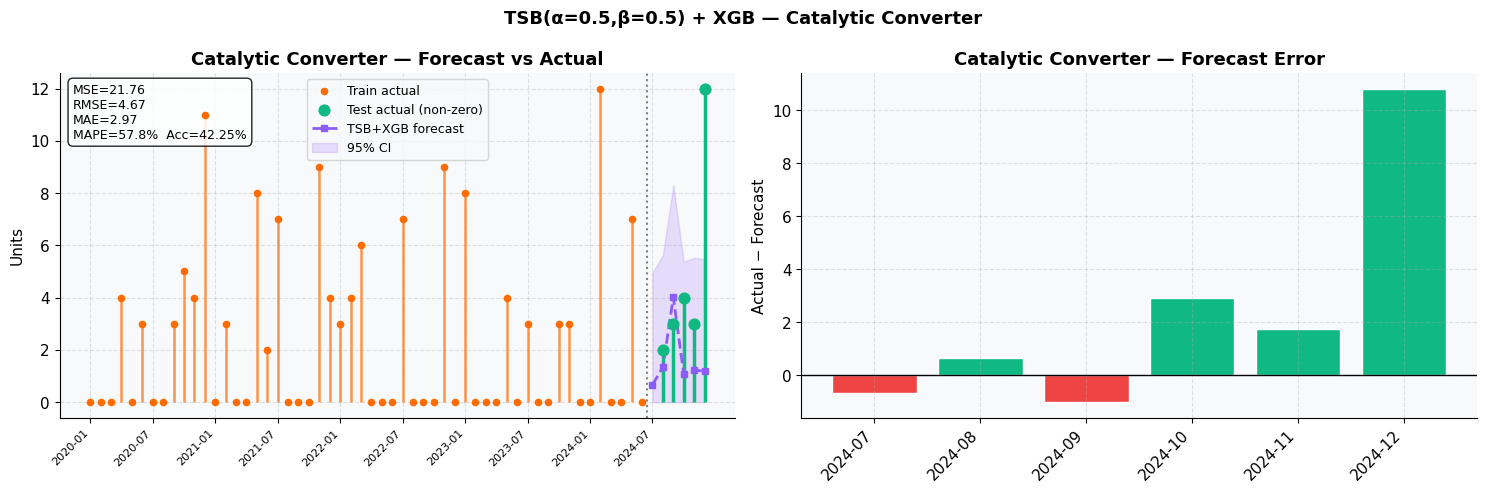

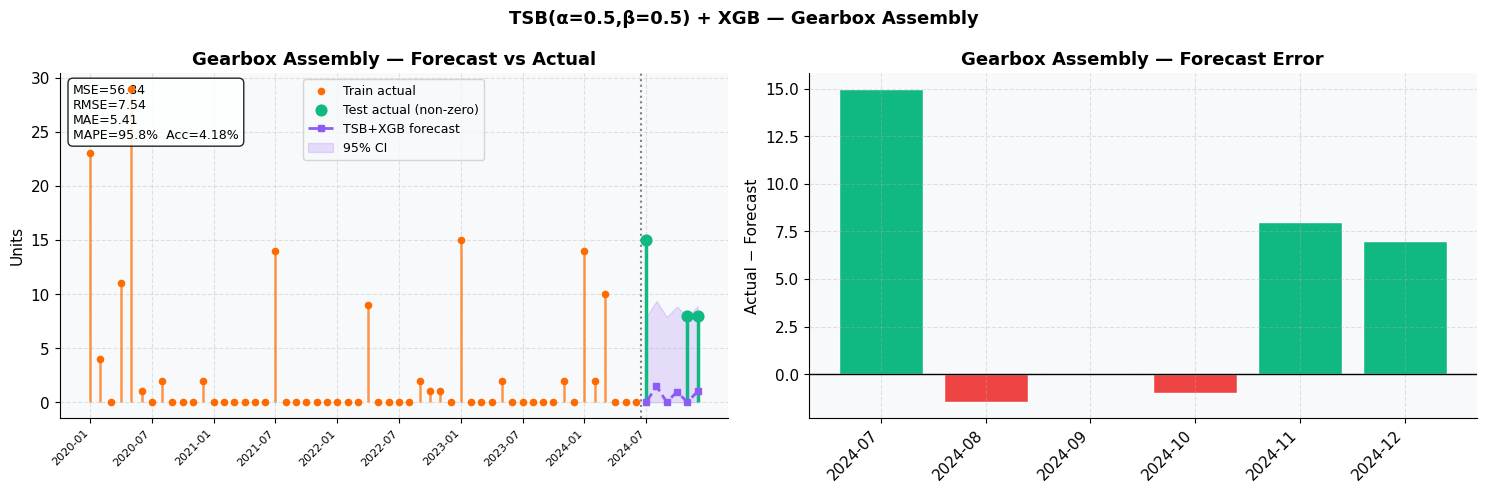

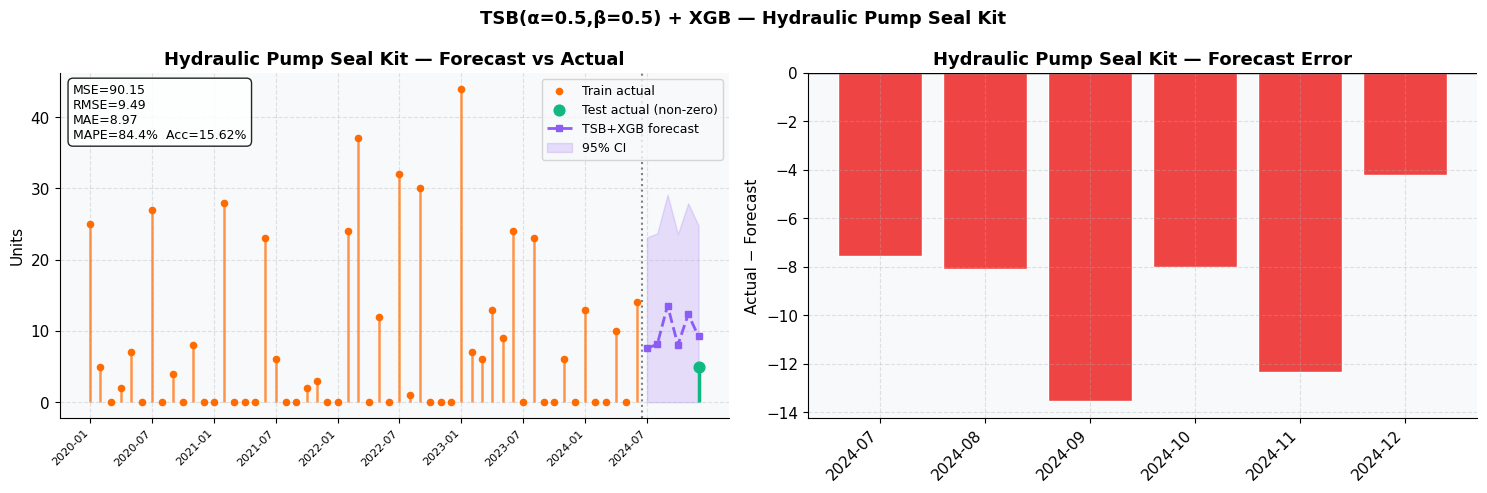

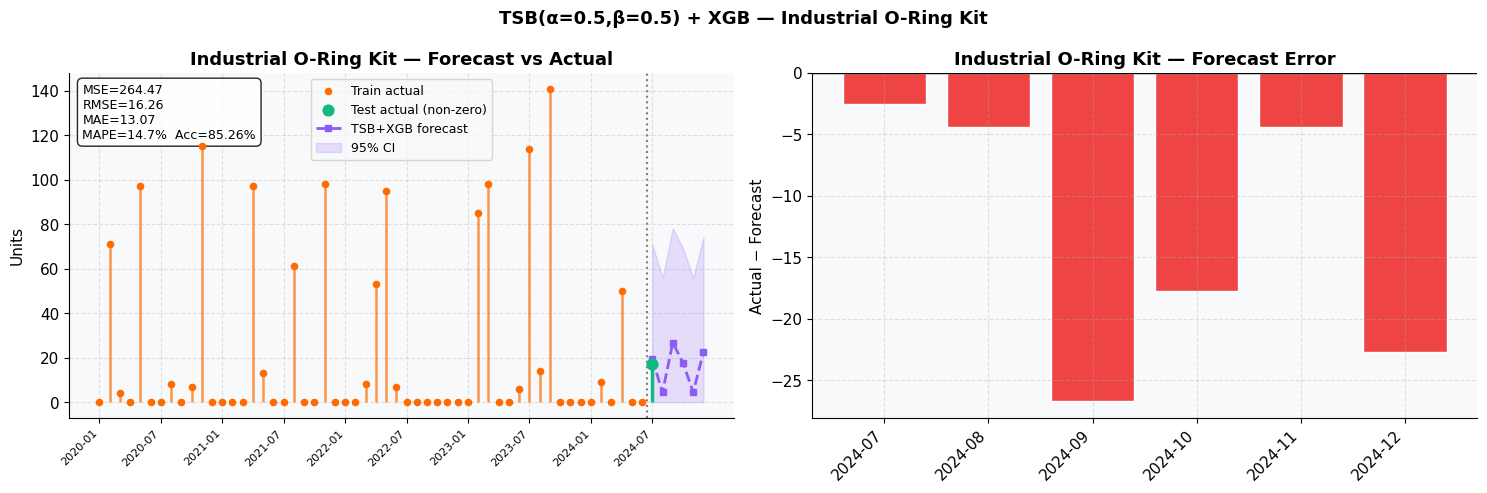

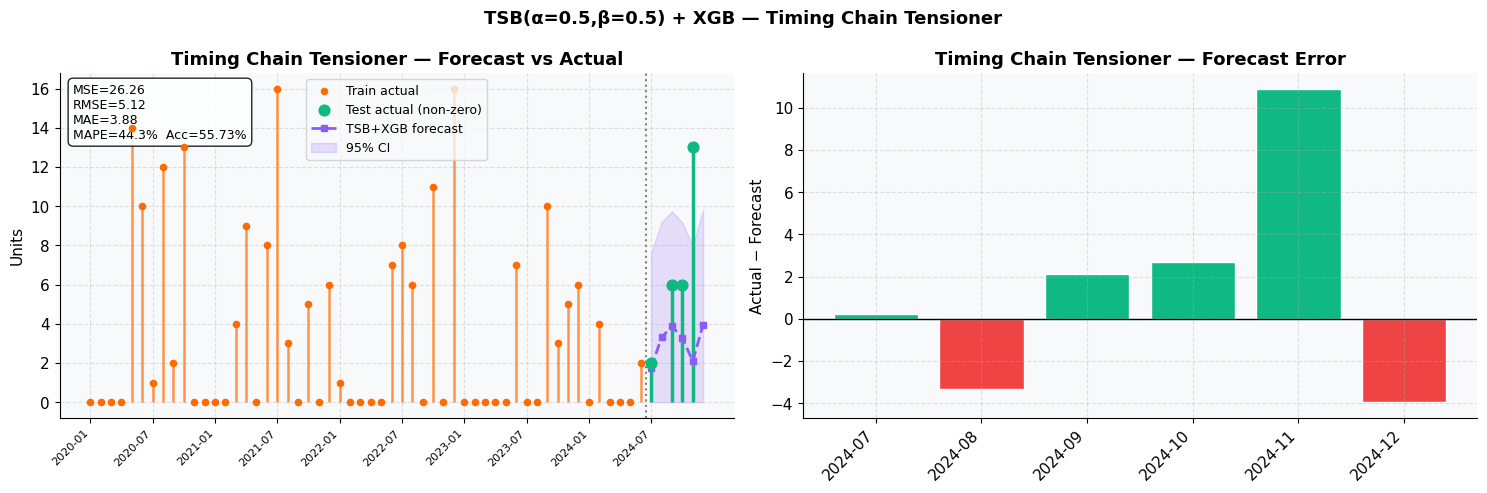

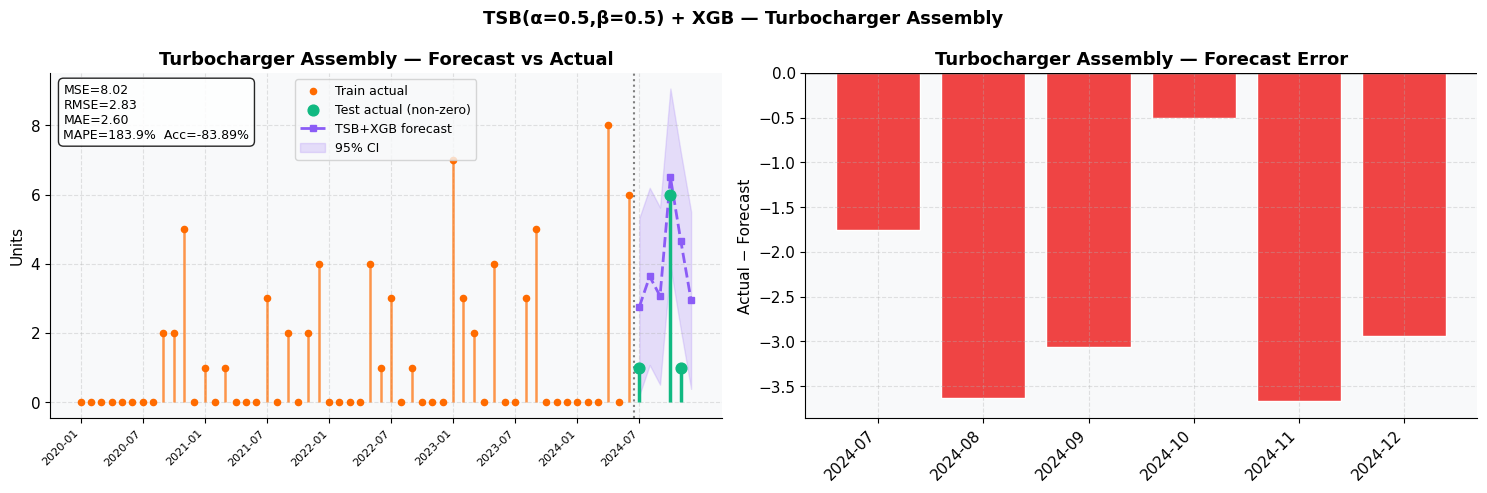

In [10]:
for prod, m in final_models.items():
    fc       = m['forecast']
    actual   = m['test_actual']
    full_arr = m['full_arr']
    full_idx = m['full_idx']
    n_train  = m['n_train']
    ci       = m['ci_hw']

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ax = axes[0]

    train_x = range(n_train)
    test_x  = range(n_train, n_train+FINAL_TEST_SIZE)

    # Stem for intermittent series
    ax.vlines(train_x, 0, full_arr[:n_train], colors=ORANGE, lw=1.8, alpha=0.7)
    ax.scatter(train_x, full_arr[:n_train], color=ORANGE, s=20, zorder=5, label='Train actual')

    ax.vlines([x for x in test_x if actual[x-n_train]>0],
              0, [actual[x-n_train] for x in test_x if actual[x-n_train]>0],
              colors=GREEN, lw=2.5)
    ax.scatter([x for x in test_x if actual[x-n_train]>0],
               [actual[x-n_train] for x in test_x if actual[x-n_train]>0],
               color=GREEN, s=60, zorder=6, label='Test actual (non-zero)')

    ax.plot(test_x, fc, color=PURPLE, lw=2, ls='--', marker='s', ms=5, label='TSB+XGB forecast')
    ax.fill_between(test_x, np.maximum(0,fc-ci), fc+ci, alpha=0.18, color=PURPLE, label='95% CI')
    ax.axvline(n_train-0.5, color='gray', ls=':', lw=1.5)

    met = m['metrics']
    mape_s = f'{met["MAPE"]:.1f}%' if not np.isnan(met['MAPE']) else 'N/A'
    ax.text(0.02, 0.97,
            f'MSE={met["MSE"]:.2f}\nRMSE={met["RMSE"]:.2f}\nMAE={met["MAE"]:.2f}\nMAPE={mape_s}  Acc={met["Accuracy"]}%',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.4',facecolor='white',alpha=0.85))

    step = max(1, len(full_idx)//10)
    ax.set_xticks(list(range(0,len(full_idx),step)))
    ax.set_xticklabels([str(full_idx[i]) for i in range(0,len(full_idx),step)],
                       rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{prod} — Forecast vs Actual')
    ax.set_ylabel('Units'); ax.legend(fontsize=9)

    # Right: per-period error
    ax2  = axes[1]
    err  = actual - fc
    xlbls= [str(full_idx[-FINAL_TEST_SIZE+i]) for i in range(FINAL_TEST_SIZE)]
    clrs = [GREEN if e>=0 else '#ef4444' for e in err]
    ax2.bar(range(FINAL_TEST_SIZE), err, color=clrs, edgecolor='white')
    ax2.axhline(0, color='black', lw=1)
    ax2.set_xticks(range(FINAL_TEST_SIZE))
    ax2.set_xticklabels(xlbls, rotation=45, ha='right')
    ax2.set_title(f'{prod} — Forecast Error')
    ax2.set_ylabel('Actual − Forecast')

    plt.suptitle(f'TSB(α={m["best_alpha"]},β={m["best_beta"]}) + XGB — {prod}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    slug = prod.lower().replace(' ','_').replace('/','_')
    plt.savefig(f'tsb_final_forecast_{slug}.png', dpi=120, bbox_inches='tight')
    plt.show()

## 10. Load from Pickle & Run Inference

In [11]:
example_prod = tsb_products[0]
pkl_path     = PICKLE_DIR / f'{example_prod.lower().replace(" ","_").replace("/","_").replace("-","_")}.pkl'

with open(pkl_path,'rb') as f:
    loaded = pickle.load(f)

print(f'Loaded model for : {loaded["product"]}')
print(f'  Algorithm      : {loaded["algorithm"]}')
print(f'  Best α (size)  : {loaded["best_alpha"]}')
print(f'  Best β (prob)  : {loaded["best_beta"]}')
print(f'  Trained at     : {loaded["trained_at"]}')
print(f'  Train months   : {loaded["n_train"]}')
met = loaded['metrics']
mape_s = f'{met["MAPE"]}%' if not np.isnan(met['MAPE']) else 'N/A'
print(f'  Saved metrics  : MSE={met["MSE"]}  RMSE={met["RMSE"]}  MAE={met["MAE"]}  MAPE={mape_s}')

# ── Inference: next 6 months ──────────────────────────────────────────────────
xgb_mod   = loaded['xgb_model']
scaler    = loaded['scaler']
residuals = np.array(loaded['residuals'])
tsb_last  = float(loaded['tsb_fitted'][-1])
ci_hw     = loaded['ci_hw']
NEW_HOR   = 6

tsb_fc_base = np.full(NEW_HOR, tsb_last)
xgb_corr    = []
window = list(residuals)
for _ in range(NEW_HOR):
    feat = extract_feat(window)
    c    = float(xgb_mod.predict(scaler.transform([feat]))[0])
    xgb_corr.append(c); window.append(c)

new_fc = np.maximum(0, tsb_fc_base + np.array(xgb_corr))
last_period = pd.Period(loaded['train_index'][-1], freq='M')
future = [str(last_period+i) for i in range(1, NEW_HOR+1)]

print(f'\n📅  Inference — next {NEW_HOR} months:')
print(f'  {"Period":<12} {"Forecast":>10} {"Lower95":>10} {"Upper95":>10}')
for p, v in zip(future, new_fc):
    lo = max(0, v-ci_hw); hi = v+ci_hw
    print(f'  {p:<12} {v:>10.1f} {lo:>10.1f} {hi:>10.1f}')

Loaded model for : Catalytic Converter
  Algorithm      : TSB_XGB
  Best α (size)  : 0.5
  Best β (prob)  : 0.5
  Trained at     : 2026-03-26T13:26:15.075589
  Train months   : 54
  Saved metrics  : MSE=21.762  RMSE=4.665  MAE=2.9733  MAPE=57.75%

📅  Inference — next 6 months:
  Period         Forecast    Lower95    Upper95
  2024-07             0.7        0.0        5.0
  2024-08             1.3        0.0        5.6
  2024-09             4.0        0.0        8.3
  2024-10             1.1        0.0        5.4
  2024-11             1.2        0.0        5.5
  2024-12             1.2        0.0        5.5


## 11. Pickle Contents Summary

In [12]:
pkl_files = sorted(PICKLE_DIR.glob('*.pkl'))
print(f'Saved pickle files in {PICKLE_DIR}/')
print(f'{"─"*60}')
total = 0
for p in pkl_files:
    sz = p.stat().st_size; total += sz
    with open(p,'rb') as f: b = pickle.load(f)
    met = b['metrics']
    mape_s = f'{met["MAPE"]}%' if not np.isnan(met['MAPE']) else 'N/A'
    print(f'  {p.name:<50} {sz/1024:>6.1f} KB')
    print(f'    α={b["best_alpha"]}  β={b["best_beta"]}  MAPE={mape_s}  Acc={met["Accuracy"]}%')
print(f'{"─"*60}')
print(f'  Total: {total/1024:.1f} KB  ({len(pkl_files)} files)')
print(f'\nTo reload:')
print("  import pickle")
print("  with open('autoparts-backend/python/trained_models/tsb_xgb/<product>.pkl','rb') as f:")
print("      bundle = pickle.load(f)")
print("  xgb_model = bundle['xgb_model']")
print("  scaler    = bundle['scaler']")
print("  tsb_last  = float(bundle['tsb_fitted'][-1])")

Saved pickle files in tsb_xgb_models/
────────────────────────────────────────────────────────────
  tsb_xgb_catalytic_converter.pkl                     239.8 KB
    α=0.5  β=0.5  MAPE=57.75%  Acc=42.25%
  tsb_xgb_gearbox_assembly.pkl                        243.7 KB
    α=0.5  β=0.5  MAPE=95.82%  Acc=4.18%
  tsb_xgb_hydraulic_pump_seal_kit.pkl                 254.7 KB
    α=0.5  β=0.5  MAPE=84.38%  Acc=15.62%
  tsb_xgb_industrial_o-ring_kit.pkl                   261.7 KB
    α=0.5  β=0.5  MAPE=14.74%  Acc=85.26%
  tsb_xgb_timing_chain_tensioner.pkl                  254.3 KB
    α=0.5  β=0.5  MAPE=44.27%  Acc=55.73%
  tsb_xgb_turbocharger_assembly.pkl                   238.6 KB
    α=0.5  β=0.5  MAPE=183.89%  Acc=-83.89%
────────────────────────────────────────────────────────────
  Total: 1492.9 KB  (6 files)

To reload:
  import pickle
  with open('tsb_xgb_models/tsb_xgb_<product>.pkl','rb') as f:
      bundle = pickle.load(f)
  xgb_model = bundle['xgb_model']
  scaler    = bundle['sc